<a href="https://colab.research.google.com/github/Ewha-Euron/10th-ML/blob/week_11/%EB%B3%B5%EC%8A%B5%EB%AC%B8%EC%A0%9C_11%EC%A3%BC%EC%B0%A8_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 11주차 복습과제: 군집화

다음은 11주차 군집화 세션의 복습과제입니다. 문제 조건에 맞춰 코드를 작성하고, 설명을 추가해 주세요.

---

#Section A: 군집화, K-means

문제 1: 좋은 군집화란?

좋은 군집화의 조건을 설명하시오.

**요구 사항**

군집 내부 응집도(Within-cluster similarity)의 의미를 설명하시오.

군집 간 분리도(Between-cluster dissimilarity)의 의미를 설명하시오.



군집 내부 응집도 : 동일한 군집에 소간 데이터 포인트들끼리 얼마나 서로 가깝고 유사한지를 의미합니다. 좋은 군집화가 되려면 군집 내부의 데이터들이 중심점을 기준으로 빽빽하게 모여 있어 응집도가 높아야(거리의 합이 최소화되어야) 합니다.

군집 간 분리도 : 서로 다른 군집들이 얼마나 명확하게 떨어져 있는지를 의미합니다. 좋은 군집화가 되려면 서로 다른 군집 간의 중심점 거리가 멀어서 분리도가 높아야 (경계가 명확해야) 합니다.

문제 2: K-Means에서 군집 개수 K는 매우 중요한 파라미터이다.
동일한 데이터에 대해 서로 다른 K값을 적용했을 때 군집화 결과가 어떻게 달라지는지 비교하시오.

데이터 생성 조건
샘플 수 : 400개
군집 수 : 4개
특징 수 : 2개
random_state : 0
수행 조건

다음 K값에 대해 각각 군집화를 수행하시오.

Case 1 : K = 2
Case 2 : K = 4
Case 3 : K = 6
(배운 파라미터를 기반으로 작성하면 됨)

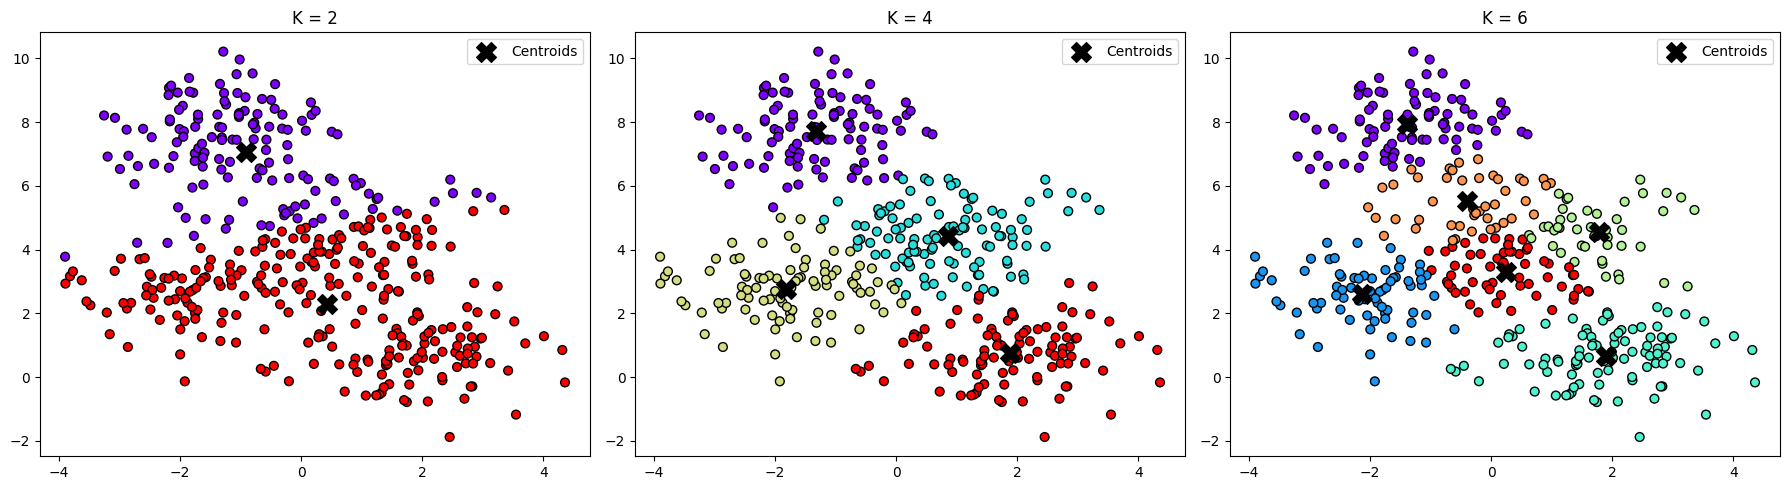

In [2]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 데이터 생성
X, y = make_blobs(n_samples=400, centers=4, n_features=2, random_state=0)

# K값 후보 설정
k_values = [2, 4, 6]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, k in enumerate(k_values):
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = kmeans.fit_predict(X)

    # 결과 시각화
    axes[i].scatter(X[:, 0], X[:, 1], c=labels, cmap='rainbow', edgecolor='k', s=40)
    axes[i].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                    s=200, marker='X', c='black', label='Centroids')
    axes[i].set_title(f'K = {k}')
    axes[i].legend()

plt.tight_layout()
plt.show()

문제 3 : Elbow Method - 최적 K찾기

K-Means는 사전에 K값을 지정해야 하기 때문에 적절한 군집 개수를 선택하는 과정이 중요하다. Elbow Method를 사용하여 최적의 군집 수를 탐색하시오. 데이터 생성 조건 샘플 수 : 500개 군집 수 : 5개 특징 수 : 2개 random_state : 10

수행 조건 K를 1부터 10까지 변화시키며 K-Means 수행

K값에 따른 SSE 그래프를 그리시오.

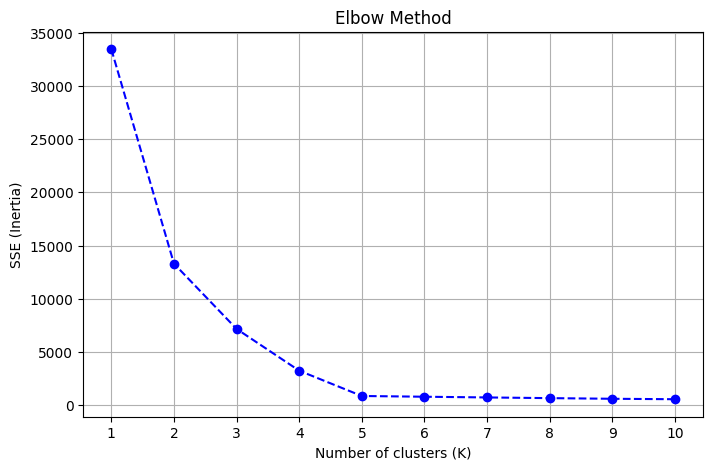

In [3]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 데이터 생성
X, y = make_blobs(
    n_samples=500,
    centers=5,
    n_features=2,
    random_state=10
)

sse = []
# K를 1부터 10까지 변화시키며 K-Means 수행
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=10, n_init=10)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)  # inertia_ 속성이 SSE를 의미함

# K값에 따른 SSE 그래프 시각화
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), sse, marker='o', color='b', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (K)')
plt.ylabel('SSE (Inertia)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

문제 4: make_blobs를 이용해 2차원 데이터를 생성하고,
K=3으로 K-Means 군집화를 수행하시오.

centroid를 함께 시각화할 것
random_state=42 사용

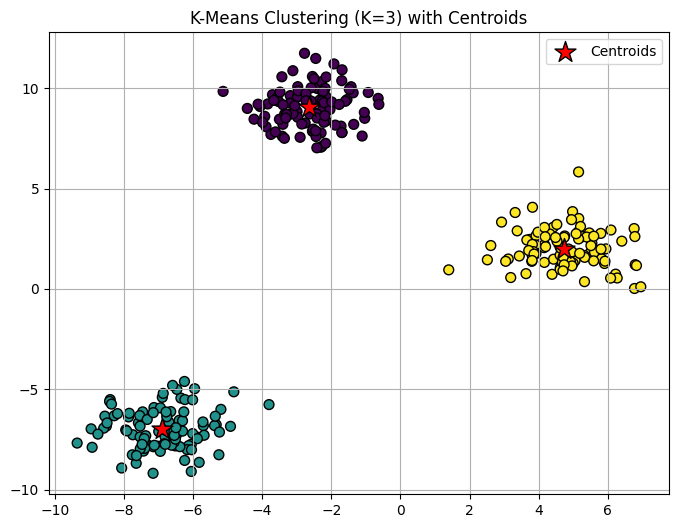

In [4]:
# 데이터 생성
X, y = make_blobs(n_samples=300, centers=3, n_features=2, random_state=42) # 일반적인 샘플수 지정

# K=3 K-Means 수행
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

# 시각화 (Centroid 포함)
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolor='k', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=250, marker='*', c='red', edgecolor='black', label='Centroids')
plt.title('K-Means Clustering (K=3) with Centroids')
plt.legend()
plt.grid(True)
plt.show()

문제 5:
iris 데이터셋에 대해
K=2
K=8로 각각 K-Means 군집화를 수행하고 결과를 시각화하시오.


이를 통해
K가 너무 작을 때의 문제점
K가 너무 클 때의 문제점을 서술하시오.

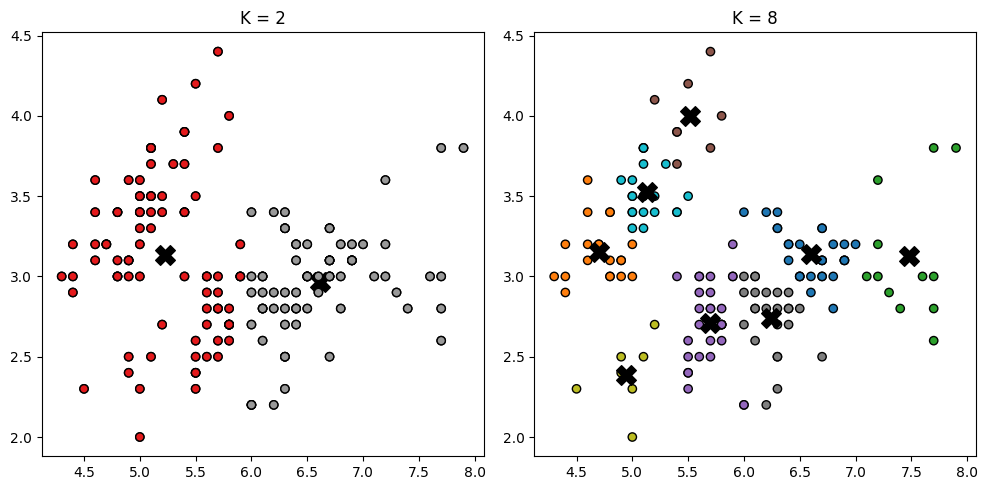

In [5]:
# iris data 불러오기
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# iris 데이터 불러오기
iris = load_iris()
X = iris.data[:, :2]   # 앞 2개 feature만 사용

# subplot 생성
fig, axes = plt.subplots(1, 2, figsize=(10,5))

# K=2 수행 및 시각화
kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_2 = kmeans_2.fit_predict(X)
axes[0].scatter(X[:, 0], X[:, 1], c=labels_2, cmap='Set1', edgecolor='k')
axes[0].scatter(kmeans_2.cluster_centers_[:, 0], kmeans_2.cluster_centers_[:, 1], s=200, marker='X', c='black')
axes[0].set_title('K = 2')

# K=8 수행 및 시각화
kmeans_8 = KMeans(n_clusters=8, random_state=42, n_init=10)
labels_8 = kmeans_8.fit_predict(X)
axes[0].scatter(X[:, 0], X[:, 1], c=labels_2, cmap='Set1', edgecolor='k') # 기존 그래프 축 유지
axes[1].scatter(X[:, 0], X[:, 1], c=labels_8, cmap='tab10', edgecolor='k')
axes[1].scatter(kmeans_8.cluster_centers_[:, 0], kmeans_8.cluster_centers_[:, 1], s=200, marker='X', c='black')
axes[1].set_title('K = 8')

plt.tight_layout()
plt.show()

- K가 너무 작을 때의 문제점 : 실제 데이터 구조보다 적은 수의 군집을 생성하므로, 서로 다른 특성을 가진 이질적인 데이터 그룹이 하나의 군집으로 과도하게 묶이게 됩니다. 이로 인해 군집 내부의 응집도가 크게 떨어집니다.

- K가 너무 클 때의 문제점 : 실제 데이터 패턴을 반영하지 못하고 하나의 의미있는 군집이 불필요하게 쪼개지는 현상이 발생합니다(과적합). 개별 군비의 의미를 해석하기 어려워지고 변동성에 민감해집니다.

문제 6:

실루엣 계수(Silhouette Score)가 무엇인지 간단히 설명하시오.

실루엣 계수가 1, 0, 음수에 가까울 때 각각 어떤 의미를 가지는지 설명하시오.

- 실루엣 계수 : 군집화의 품질을 평가하는 지표로, 개별 데이터가 자신이 속한 군집 내의 데이터와 얼마나 가깝고(응집도), 가장 가까운 이웃과는 얼마나 멀리 떨어져 있는지(분리도)를 계산하여 수치화한 것입니다.

- 1에 가까울 때 : 해당 데이터 포인트가 자신이 속한 군집과 매우 잘 어울리고, 타 군집과는 명확히 분리되어 있어 이상적인 군집화가 이루어졌음을 뜻합니다.

- 0에 가까울 때 : 서로 다른 군집 간의 경계선상에 데이터들이 걸쳐져 있어서 군집 간 구분이 모호함을 뜻합니다.

- 음수에 가까울 때 : 데이터 포인트가 완전히 잘못된 군집에 할당되었음을 의미합니다.

문제 7:
iris 데이터셋에 대해 다음 조건으로 K-Means 군집화를 수행하시오.

**요구사항**

군집화를 수행하고 결과를 시각화하시오.

cluster_centers_를 출력하시오.

--- Cluster Centers ---
[[6.81276596 3.07446809]
 [5.77358491 2.69245283]
 [5.006      3.428     ]]


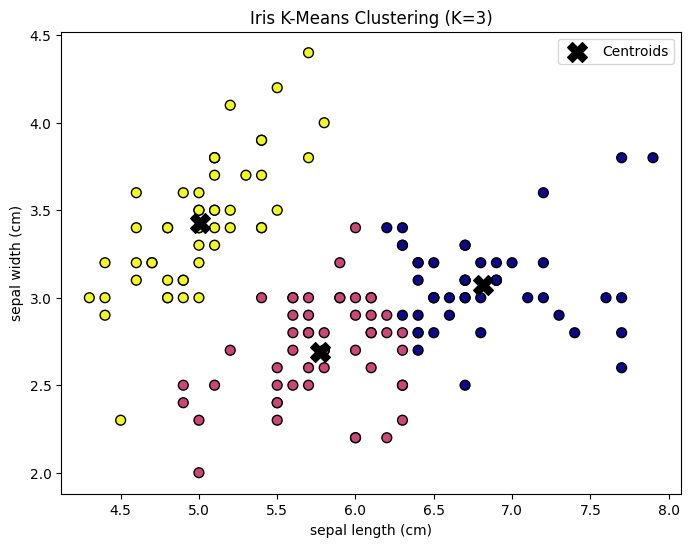

In [7]:
kmeans_model = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42
)
labels = kmeans_model.fit_predict(X)

# 1. cluster_centers_ 출력
print("--- Cluster Centers ---")
print(kmeans_model.cluster_centers_)

# 2. 결과 시각화 (첫 2개 특징 기준 축 표현)
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='plasma', edgecolor='k', s=50)
plt.scatter(kmeans_model.cluster_centers_[:, 0], kmeans_model.cluster_centers_[:, 1],
            s=200, marker='X', c='black', label='Centroids')
plt.title('Iris K-Means Clustering (K=3)')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.legend()
plt.show()

문제 8: 다음 파라미터들의 역할을 간단히 설명하시오.

n_clusters : 생성할 군집의 개수(K)를 지정합니다. 즉, 데이터를 몇 개의 그룹으로 나눌지 정의합니다.

init : 초기 군집 중심점(Centroid)의 배치 방식을 설정합니다. 무작위 배치 대신 중심점 간 거리를 넓혀서 시작하는 'k-means++' 방식이 주로 사용됩니다.

n_init : 알고리즘을 각기 다른 무작위 중심점에서 시작하여 총 몇 번 반복 실행할지 결정합니다. 이 중 가장 SSE가 낮은 최적의 결과를 최종 모델로 선택합니다.

max_iter : 중심점 이동을 위한 단일 실행닫 최대 반복 횟수를 지정합니다. 중심점이 더 이상 변하지 않으면 이 횟수 도달 전에 조기 종료됩니다.

random_state : 무작위 초기 중심점 선정 시 결과의 재현성을 보장하기 위해 고정하는 난수 시드값입니다.

### Section B: 평균 이동, GMM, DBSCAN

#### 문제 1: 평균 이동(Mean Shift) 군집화의 이해

Mean Shift 알고리즘은 KMeans와 유사하게 거리 기반 군집화 방법 중 하나입니다. 이 알고리즘의 동작 방식에 대해 간략히 설명하고, `make_blobs`를 사용하여 가상의 데이터셋을 생성한 후 `MeanShift`를 적용하여 군집화를 수행하고 결과를 시각화하세요.

**데이터 생성 조건:**
- 샘플 수: 300개
- 군집 수: 3개
- 특징 수: 2개
- 랜덤 시드: 42

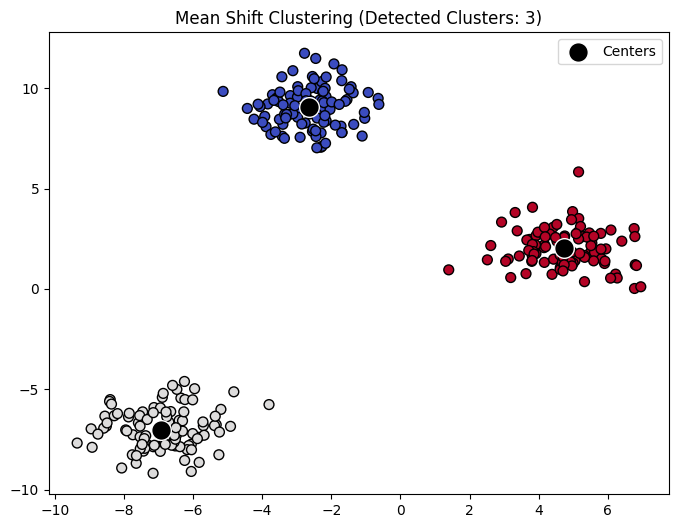

In [9]:
from sklearn.cluster import MeanShift
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np

# 데이터 생성
X, y = make_blobs(n_samples=300, centers=3, n_features=2, random_state=42)

# Mean Shift 수행
meanshift = MeanShift()
labels = meanshift.fit_predict(X)

# 시각화
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='coolwarm', edgecolor='k', s=50)
plt.scatter(meanshift.cluster_centers_[:, 0], meanshift.cluster_centers_[:, 1],
            s=200, marker='o', c='black', edgecolor='w', label='Centers')
plt.title(f'Mean Shift Clustering (Detected Clusters: {len(np.unique(labels))})')
plt.legend()
plt.show()

#### 문제 2: Mean Shift 군집화 파라미터 이해 및 조정

Mean Shift 알고리즘에서 `bandwidth` 파라미터는 군집화 결과에 큰 영향을 미칩니다. `bandwidth` 값을 다르게 설정했을 때 군집화 결과가 어떻게 달라지는지 확인하기 위해, 다음 조건을 따라 코드를 작성하고 결과를 비교하여 설명하세요.

**데이터 생성 조건:** (문제 1과 동일)
- 샘플 수: 300개
- 군집 수: 3개
- 특징 수: 2개
- 랜덤 시드: 42

**MeanShift 설정:**
- Case 1: `bandwidth`를 `estimate_bandwidth`로 추정한 값 사용
- Case 2: `bandwidth`를 추정값의 0.5배로 설정
- Case 3: `bandwidth`를 추정값의 2배로 설정

각 Case별로 군집화 결과를 시각화하고, 군집의 개수 변화와 그 이유를 간략하게 설명하세요.

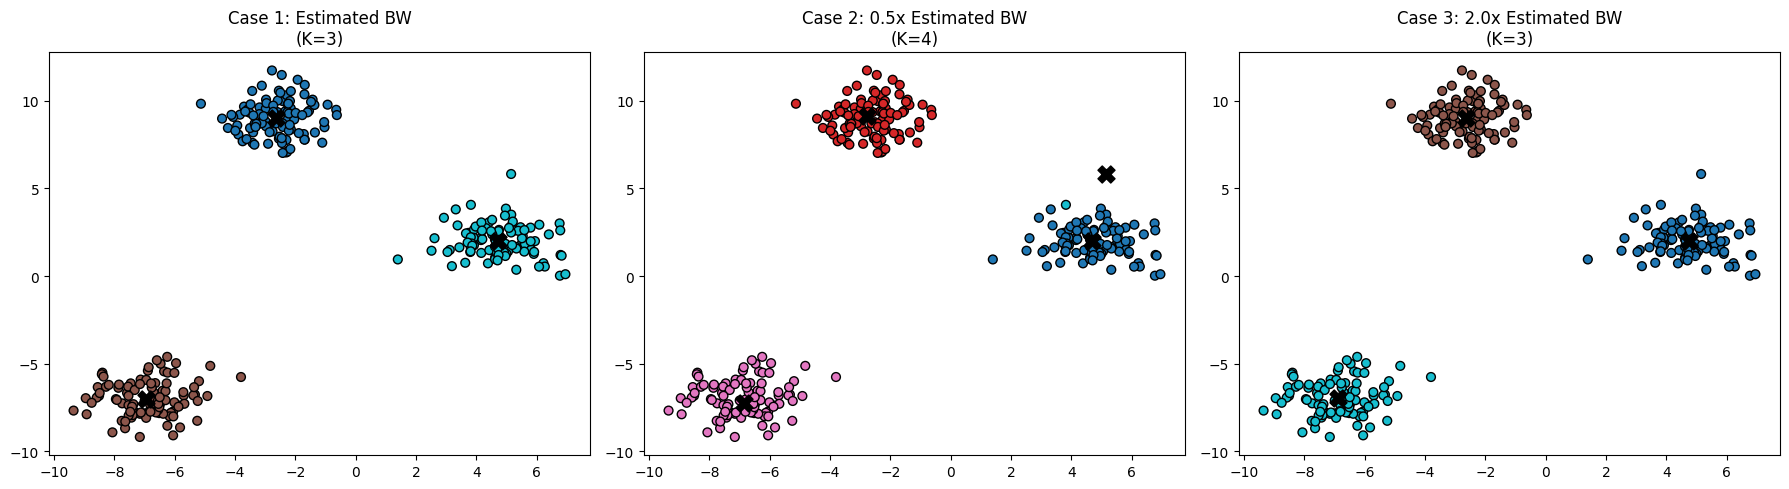

In [11]:
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np

X, y = make_blobs(n_samples=300, centers=3, n_features=2, random_state=42)

# Case 1: 기본 추정치 계산
est_bw = estimate_bandwidth(X, random_state=42)

cases = [
    ('Case 1: Estimated BW', est_bw),
    ('Case 2: 0.5x Estimated BW', est_bw * 0.5),
    ('Case 3: 2.0x Estimated BW', est_bw * 2.0)
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (title, bw) in enumerate(cases):
    ms = MeanShift(bandwidth=bw)
    labels = ms.fit_predict(X)

    axes[i].scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', edgecolor='k', s=40)
    if len(ms.cluster_centers_) > 0:
        axes[i].scatter(ms.cluster_centers_[:, 0], ms.cluster_centers_[:, 1],
                        s=150, marker='X', c='black')
    axes[i].set_title(f'{title}\n(K={len(np.unique(labels))})')

plt.tight_layout()
plt.show()

결과 설명 : bandwidth는 데이터 밀도를 측정하는 탐색 변경의 크기를 뜻합니다. 반경이 너무 작아지면(0.5배) 세밀하게 군집을 나누려 하므로 군집 수가 급격히 늘어납니다. 반대로 반경이 너무 커지면 (2배) 모든 데이터를 하나의 넓은 밀도 덩어리로 인식하므로 군집 수가 지나치게 줄어들거나 하나로 뭉치게 됩니다.

#### 문제 3: GMM (Gaussian Mixture Model) 군집화 및 KMeans와의 차이점

GMM은 각 군집이 가우시안 분포를 따른다고 가정하는 확률 기반 군집화 알고리즘입니다. GMM의 기본적인 개념과 KMeans와의 주요 차이점을 설명하고, `make_blobs`로 생성된 데이터에 `GaussianMixture`를 적용하여 군집화를 수행하고 시각화하세요.

**데이터 생성 조건:**
- 샘플 수: 400개
- 군집 수: 2개
- 특징 수: 2개
- 랜덤 시드: 0
- `cluster_std`를 각각 `[1.0, 2.5]`로 설정하여 타원형 분포를 갖도록 합니다.

**GMM 설정:**
- 군집 수: 2개
- 공분산 타입: `full`
- 랜덤 시드: 0

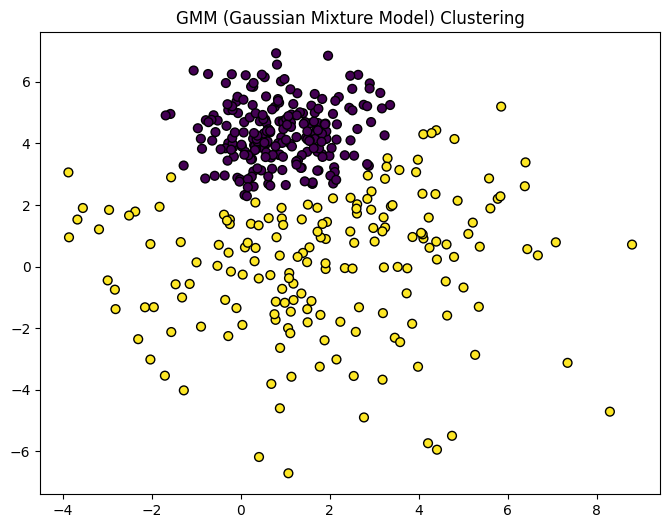

In [15]:
# 타원형 데이터 생성
X, y = make_blobs(n_samples=400, centers=2, n_features=2, random_state=0, cluster_std=[1.0, 2.5])

# GMM 모델 학습
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=0)
labels = gmm.fit_predict(X)

# 시각화
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolor='k', s=40)
plt.title('GMM (Gaussian Mixture Model) Clustering')
plt.show()

#### 문제 4: DBSCAN (밀도 기반 군집화) 알고리즘 적용

DBSCAN은 밀도 기반 군집화 방법으로, 군집의 개수를 미리 지정할 필요가 없으며 다양한 형태의 군집을 찾을 수 있습니다. DBSCAN의 주요 파라미터(`eps`, `min_samples`)와 데이터 포인트의 세 가지 유형(`Core`, `Border`, `Noise`)에 대해 설명하고, `make_moons`를 사용하여 초승달 모양 데이터셋을 생성한 후 `DBSCAN`을 적용하여 군집화를 수행하고 결과를 시각화하세요.

**데이터 생성 조건:**
- 샘플 수: 200개
- 노이즈 비율: 0.05
- 랜덤 시드: 42

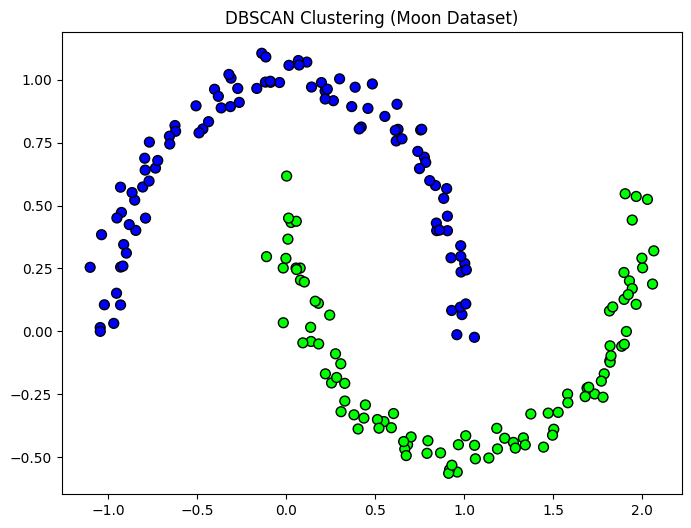

In [17]:
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# 초승달 모양 데이터 생성
X, y = make_moons(n_samples=200, noise=0.05, random_state=42)

# DBSCAN 학습 (적절한 하이퍼파라미터 eps=0.2, min_samples=5 임의 설정)
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

# 시각화 (-1은 노이즈 포인트로 분류됨)
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='brg', edgecolor='k', s=50)
plt.title('DBSCAN Clustering (Moon Dataset)')
plt.show()

### Section C: 병합 군집, 계층적 군집, 고객 세그먼테이션 (RFM)

#### 문제 5: 계층적 군집화 (Agglomerative Clustering)의 이해

계층적 군집화는 데이터를 계층적으로 묶어 트리 형태(덴드로그램)의 구조를 만듭니다. 이 중 병합 군집(Agglomerative Clustering)의 개념에 대해 설명하고, `make_blobs`로 생성된 간단한 데이터셋에 `AgglomerativeClustering`을 적용하여 군집화를 수행하고 결과를 시각화하세요.

**데이터 생성 조건:**
- 샘플 수: 100개
- 군집 수: 3개
- 특징 수: 2개
- 랜덤 시드: 42

**AgglomerativeClustering 설정:**
- 군집 수: 3개
- `linkage`: `ward`

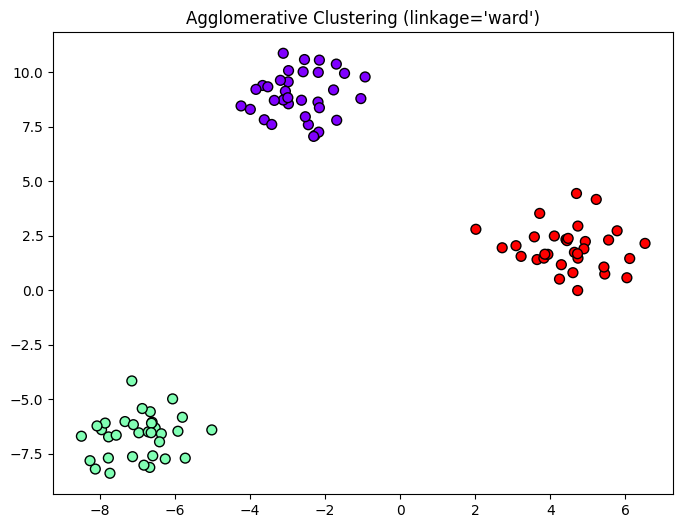

In [19]:
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

# 데이터 생성
X, y = make_blobs(n_samples=100, centers=3, n_features=2, random_state=42)

# AgglomerativeClustering 수행
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = agg.fit_predict(X)

# 시각화
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='rainbow', edgecolor='k', s=50)
plt.title('Agglomerative Clustering (linkage=\'ward\')')
plt.show()

#### 문제 6: 계층적 군집화의 Linkage 옵션

계층적 군집화에서 `linkage` 옵션은 군집 간의 유사성(거리)을 측정하는 방식을 정의하며, 군집화 결과에 중요한 영향을 미칩니다. `linkage` 옵션 중 `ward`, `complete`, `average` 세 가지 방식의 차이점을 간략히 설명하고, 다음 조건을 따라 `AgglomerativeClustering`을 적용하여 결과를 비교 시각화하세요.

**데이터 생성 조건:** (문제 5와 동일)
- 샘플 수: 100개
- 군집 수: 3개
- 특징 수: 2개
- 랜덤 시드: 42

**AgglomerativeClustering 설정:**
- 군집 수: 3개
- `linkage`: 각각 `ward`, `complete`, `average` 사용

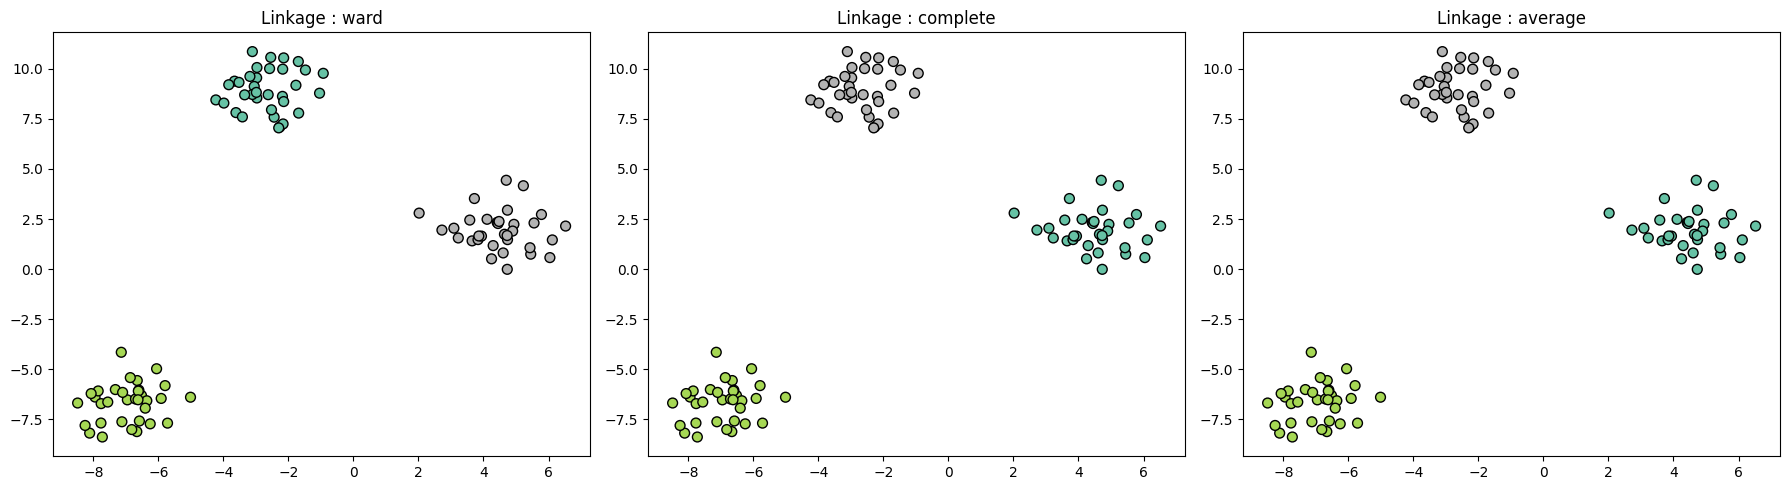

In [20]:
X, y = make_blobs(n_samples=100, centers=3, n_features=2, random_state=42)
linkages = ['ward', 'complete', 'average']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, link in enumerate(linkages):
    agg = AgglomerativeClustering(n_clusters=3, linkage=link)
    labels = agg.fit_predict(X)

    axes[i].scatter(X[:, 0], X[:, 1], c=labels, cmap='Set2', edgecolor='k', s=50)
    axes[i].set_title(f'Linkage : {link}')

plt.tight_layout()
plt.show()

#### 문제 7: 고객 세그먼테이션 (RFM 기법)의 개념

고객 세그먼테이션은 마케팅 분야에서 고객을 유사한 특성별로 그룹화하는 데 사용됩니다. 이 중 RFM (Recency, Frequency, Monetary) 기법은 가장 널리 사용되는 방법 중 하나입니다. RFM 각 지표의 의미를 설명하고, 왜 이 세 가지 지표가 고객 가치를 평가하고 세그먼테이션하는 데 효과적인지 간략하게 서술하세요.

## RFM 지표의 의미

- Recency(최근성) : 고객이 가장 최근에 서비스를 이용하거나 물건을 구매한 시점이 언제인지를 일수 등으로 측정한 지표

- Frequency(활동 빈도) : 정해진 기간 동안 고객이 구매나 방문을 얼마나 자주 반복했는지 횟수를 측정한 지표입니다.

- Monetary(구매 금액) : 고객이 누적으로 지출한 총 금액의 합계를 뜻합니다.

- 효과적인 이유 : 기업 입장에서 대규모 고객 행동 데이터를 직관적이면서도 강력한 3가지 핵심 축으로 정량화해 줍니다. 이를 통해 휴면 고객 복귀 프로모션, 우수 고객 타겟 마케팅 등 비즈니스 가치에 직결되는 타겟층 구성을 명확하고 효율적으로 세그먼테이션할 수 있기 때문에 유용합니다.

#### 문제 8: RFM 특징 데이터 전처리 및 생성

주어진 가상의 거래 데이터셋을 사용하여 RFM (Recency, Frequency, Monetary) 특징을 생성하세요. RFM은 고객 세그먼테이션을 위한 핵심 지표입니다. 각 RFM 지표를 계산하고, 최종적으로 고객별 RFM 데이터프레임을 생성하세요.

**데이터셋:** 다음 딕셔너리 형태의 데이터를 사용하여 `DataFrame`을 생성합니다.
```python
data = {
    'CustomerID': [1, 1, 1, 2, 2, 3, 3, 3, 3, 4, 4, 5, 5],
    'PurchaseDate': ['2023-01-10', '2023-01-15', '2023-02-01', '2023-01-20', '2023-02-10', '2023-01-05', '2021-03-01', '2023-02-15', '2023-02-20', '2023-01-25', '2023-02-05', '2023-01-01', '2023-01-08'],
    'Price': [100, 150, 200, 50, 120, 300, 100, 150, 80, 250, 70, 500, 100]
}
```

**계산 기준일:** `2023-03-01` (이 날짜를 기준으로 Recency를 계산합니다.)

**RFM 지표 계산:**
1. `PurchaseDate` 컬럼을 `datetime` 타입으로 변환합니다.
2. 각 고객(`CustomerID`)별로 다음 RFM 지표를 계산합니다.
   - **Recency:** `계산 기준일`로부터 가장 '최근' 구매일까지의 일수 (작을수록 좋음)
   - **Frequency:** 일정 기간 동안의 총 구매 '횟수'
   - **Monetary:** 일정 기간 동안의 총 구매 '금액' (Price의 합계)
3. 최종적으로 `CustomerID`, `Recency`, `Frequency`, `Monetary` 컬럼을 포함하는 RFM 데이터프레임을 생성하고 첫 5행을 출력합니다.

In [22]:
import pandas as pd

# 가상 데이터 생성 및 데이터프레임 구축
data = {
    'CustomerID': [1, 1, 1, 2, 2, 3, 3, 3, 3, 4, 4, 5, 5],
    'PurchaseDate': ['2023-01-10', '2023-01-15', '2023-02-01', '2023-01-20', '2023-02-10', '2023-01-05', '2021-03-01', '2023-02-15', '2023-02-20', '2023-01-25', '2023-02-05', '2023-01-01', '2023-01-08'],
    'Price': [100, 150, 200, 50, 120, 300, 100, 150, 80, 250, 70, 500, 100]
}
df = pd.DataFrame(data)

# 1. PurchaseDate 컬럼을 datetime 타입으로 변환
df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'])

# 계산 기준일 정의
target_date = pd.to_datetime('2023-03-01')

# 2~3. 각 고객(CustomerID)별로 RFM 지표 집계 처리
rfm_df = df.groupby('CustomerID').agg({
    # Recency: 기준일 - 가장 최근(최대값) 구매일
    'PurchaseDate': lambda x: (target_date - x.max()).days,
    # Frequency: 방문/구매 건수 카운트
    'CustomerID': 'count',
    # Monetary: 총 금액 합산
    'Price': 'sum'
})

# 컬럼명 재정의
rfm_df.columns = ['Recency', 'Frequency', 'Monetary']
rfm_df = rfm_df.reset_index()

# 최종 데이터프레임의 상위 5행 출력
print(rfm_df.head())

   CustomerID  Recency  Frequency  Monetary
0           1       28          3       450
1           2       19          2       170
2           3        9          4       630
3           4       24          2       320
4           5       52          2       600
